# 0. Importações e Funções

In [15]:
show_processas import datasets
from keras import layers
from keras import models
from keras import utils
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

%matplotlib inline


def show_img(image,label):
  
    im_shape = image.shape

    f, ax = plt.subplots(1,1,figsize=(11,11)) 
    ax.set_xticks(range(im_shape[0]))
    ax.set_yticks(range(im_shape[1]))

    ax.imshow(image,cmap='gray')

    for i in range(im_shape[0]):
        for j in range(im_shape[1]):
            ax.text(i,j,s=str(round(image[j,i],3)),c='w',ha='center',size='x-small')

    ax.set_title(f'LABEL : {label}')
    
    
def show_process(n,autoencoder,encoder,x,y):
    
    n = 8

    f, ax = plt.subplots(3,n,figsize=(25,8))

    idxs_sample        = np.random.choice(range(x.shape[0]),n)
    original_imgs      = x[idxs_sample]
    original_labels    = y[idxs_sample]
    encoded_imgs       = encoder.predict(original_imgs).reshape(n,2,16)
    reconstructed_imgs = autoencoder.predict(original_imgs).reshape(n,28,28)


    for i in range(3):
        for j in range(n):
            if i == 0:
                ## plotando as originais
                ax[i,j].imshow(original_imgs[j].reshape(28,28),cmap='gray')
                ax[i,j].set_title(original_labels[j])
                ax[i,j].axis('off')

            elif i == 1:
                ## plotando os vetores latentes
                ax[i,j].imshow(encoded_imgs[j].reshape(2,16),cmap='gray')
                ax[i,j].axis('off')

            else:
                ## plotando os vetores latentes
                ax[i,j].imshow(reconstructed_imgs[j].reshape(28,28),cmap='gray')
                ax[i,j].axis('off')

# 1. Importando e tratados os dados

In [4]:
(x_train,y_train),(x_test,y_test) = datasets.mnist.load_data()

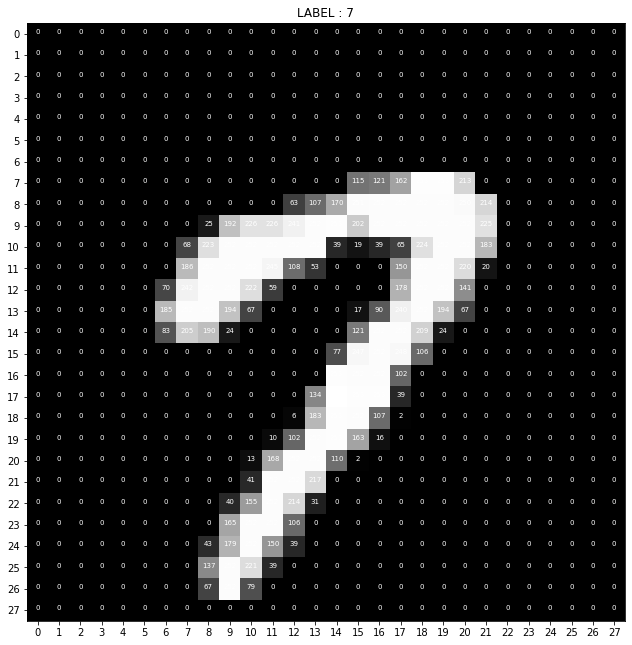

In [9]:
show_img(x_train[15],y_train[15])

In [11]:
x_train = x_train / 255
x_test = x_test / 255

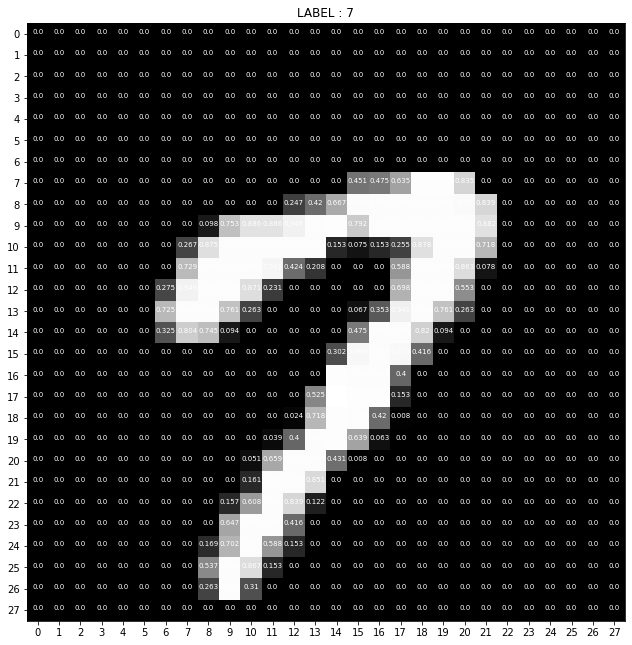

In [12]:
show_img(x_train[15],y_train[15])

# 2. Explorando os Dados

In [13]:
x_train.shape,x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [19]:
pd.Series(y_train).value_counts(normalize=True)

1    0.112367
7    0.104417
3    0.102183
2    0.099300
9    0.099150
0    0.098717
6    0.098633
8    0.097517
4    0.097367
5    0.090350
dtype: float64

# 3. Autoencoder

In [28]:
x_train = x_train.reshape(60000,784)
x_test = x_test.reshape(10000,784)

In [30]:
## camada de entrada do encoder
input_img = layers.Input(shape=(784,))

############# ENCODER #############
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)

## VETOR LATENTE
encoded = layers.Dense(32, activation='relu')(encoded)

############# DECODER #############
decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

In [36]:
## DEFINIR O MODELO

autoencoder = models.Model(input_img,decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [38]:
## DEFINIR O ENCODER

encoder = models.Model(input_img,encoded)

In [39]:
autoencoder.fit(x_train,x_train,
                epochs=500,
                batch_size=256,
                verbose=0)

In [40]:
x_train_v_latente = encoder.predict(x_train)

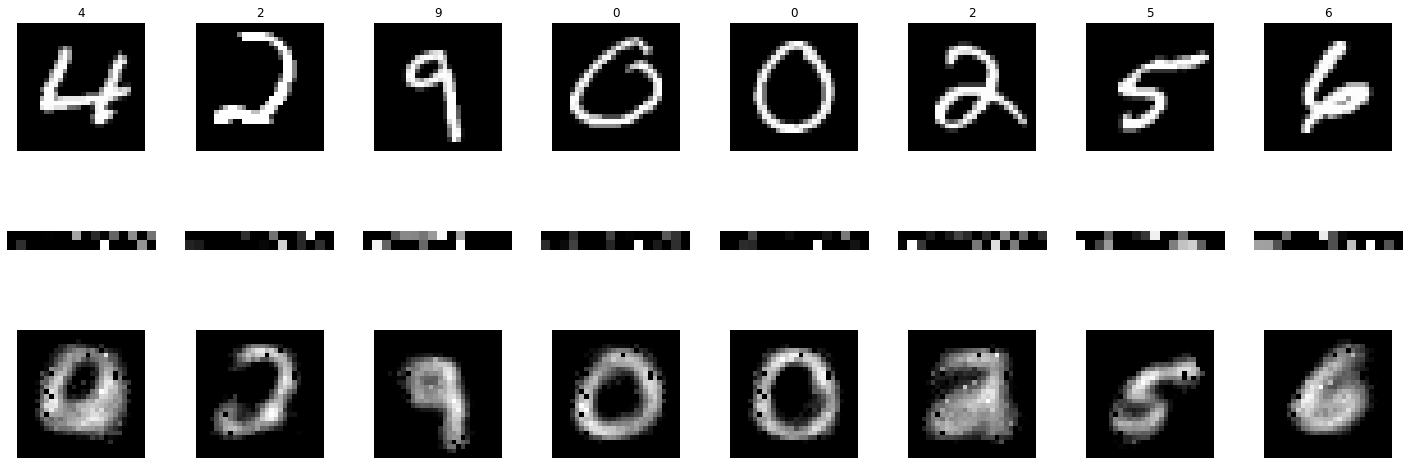

In [43]:
show_process(10,autoencoder=autoencoder,encoder=encoder,x=x_train,y=y_train)

In [52]:
input_img = layers.Input(shape=(28, 28, 1))

x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)

encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

## decoder

x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(16, (3, 3), activation='relu')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)


autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [53]:
(x_train, _), (x_test, _) = datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

In [54]:
autoencoder.fit(x_train, x_train,
                epochs=150,
                batch_size=256,
                verbose=0)

TypeError: type numpy.ndarray doesn't define __round__ method

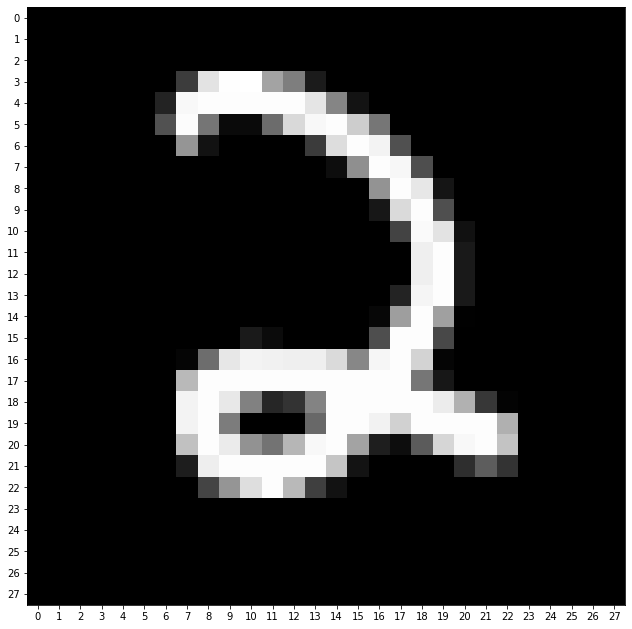

In [68]:
show_img(x_train[2354],label=5)

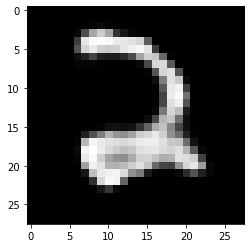

In [69]:
img_predita = autoencoder.predict(x_train[2354].reshape(1,28,28,1))

plt.imshow(img_predita.reshape(28,28),cmap='gray')